In [6]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             RocCurveDisplay)
import joblib

print("Libraries imported successfully!")
print("Working directory:", os.getcwd())

Libraries imported successfully!
Working directory: c:\Projects\traffic-congestion-prediction


In [7]:
# Load preprocessed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_val = pd.read_csv('data/processed/X_val.csv')
X_test = pd.read_csv('data/processed/X_test.csv')

y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

# Load class weights
class_weights = joblib.load('models/class_weights.pkl')

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Class weights: {class_weights}")

Data loaded successfully!
X_train shape: (1297702, 12)
X_val shape:   (278079, 12)
X_test shape:  (278079, 12)
Class weights: {np.int64(0): np.float64(0.6246850585114833), np.int64(1): np.float64(2.5050517919673227)}


In [8]:
import time

print("Training Random Forest...")
print("This may take a few minutes...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Training complete!")
print(f"Training time: {training_time:.1f} seconds")

Training Random Forest...
This may take a few minutes...
Training complete!
Training time: 61.3 seconds


In [9]:
# Predict on validation set
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

print("=== Random Forest – Validation Results ===")
print(classification_report(y_val, y_val_pred, 
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob):.4f}")

=== Random Forest – Validation Results ===
               precision    recall  f1-score   support

No Congestion       0.93      0.98      0.95    236537
   Congestion       0.82      0.60      0.69     41542

     accuracy                           0.92    278079
    macro avg       0.88      0.79      0.82    278079
 weighted avg       0.92      0.92      0.91    278079

AUC-ROC: 0.9531


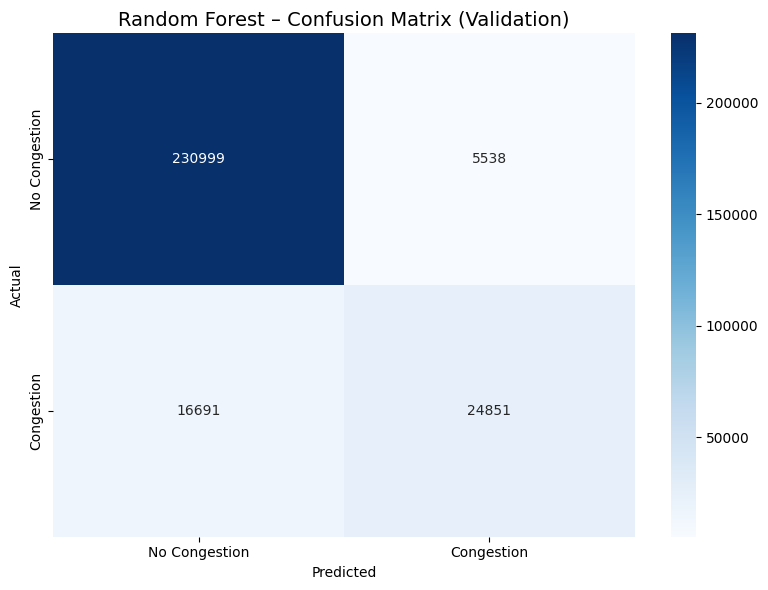

True Negatives  (correctly said no congestion): 230,999
False Positives (wrongly said congestion):      5,538
False Negatives (missed real congestion):       16,691
True Positives  (correctly said congestion):    24,851


In [10]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Congestion', 'Congestion'],
            yticklabels=['No Congestion', 'Congestion'])
ax.set_title('Random Forest – Confusion Matrix (Validation)',
             fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/figures/rf_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said no congestion): {tn:,}")
print(f"False Positives (wrongly said congestion):      {fp:,}")
print(f"False Negatives (missed real congestion):       {fn:,}")
print(f"True Positives  (correctly said congestion):    {tp:,}")

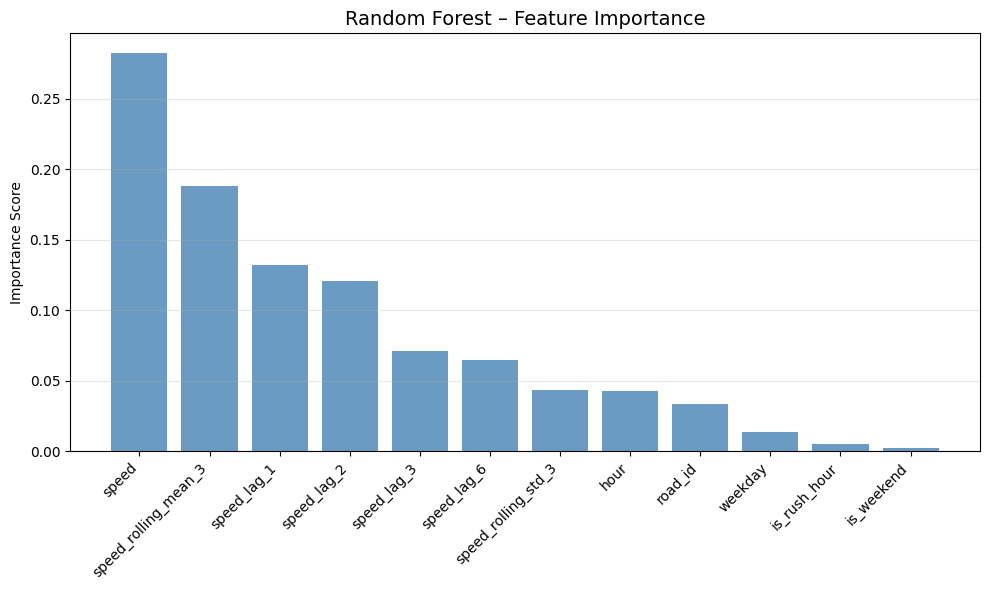

Feature importances:
  speed                    : 0.2823
  speed_rolling_mean_3     : 0.1881
  speed_lag_1              : 0.1323
  speed_lag_2              : 0.1206
  speed_lag_3              : 0.0710
  speed_lag_6              : 0.0649
  speed_rolling_std_3      : 0.0431
  hour                     : 0.0431
  road_id                  : 0.0332
  weekday                  : 0.0138
  is_rush_hour             : 0.0053
  is_weekend               : 0.0023


In [11]:
# Feature importance
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(feature_names)), 
       importances[indices],
       color='steelblue', alpha=0.8)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices],
                    rotation=45, ha='right')
ax.set_title('Random Forest – Feature Importance', fontsize=14)
ax.set_ylabel('Importance Score')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/figures/rf_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Feature importances:")
for i in indices:
    print(f"  {feature_names[i]:25s}: {importances[i]:.4f}")

In [12]:
joblib.dump(rf_model, 'models/random_forest.pkl')
print("Model saved to models/random_forest.pkl")
print(f"Model size: "
      f"{os.path.getsize('models/random_forest.pkl')/1024/1024:.1f} MB")

Model saved to models/random_forest.pkl
Model size: 1364.9 MB


In [13]:
from sklearn.metrics import f1_score, recall_score

results = []

# Store baseline results
baseline_f1 = f1_score(y_val, y_val_pred)
baseline_recall = recall_score(y_val, y_val_pred)
results.append({
    'config': 'Baseline (100 trees, no max_depth)',
    'f1': baseline_f1,
    'recall': baseline_recall,
    'training_time': 61.3
})

print(f"Baseline already done:")
print(f"  F1: {baseline_f1:.4f}")
print(f"  Recall: {baseline_recall:.4f}")
print(f"\nTraining Config 2 (100 trees, max_depth=20)...")

start = time.time()
rf_config2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_config2.fit(X_train, y_train)
t2 = time.time() - start

y_val_pred2 = rf_config2.predict(X_val)
f1_2 = f1_score(y_val, y_val_pred2)
recall_2 = recall_score(y_val, y_val_pred2)
results.append({
    'config': 'Config 2 (100 trees, max_depth=20)',
    'f1': f1_2,
    'recall': recall_2,
    'training_time': t2
})
print(f"Done in {t2:.1f}s – F1: {f1_2:.4f}, Recall: {recall_2:.4f}")

print(f"\nTraining Config 3 (200 trees, max_depth=20)...")
start = time.time()
rf_config3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_config3.fit(X_train, y_train)
t3 = time.time() - start

y_val_pred3 = rf_config3.predict(X_val)
f1_3 = f1_score(y_val, y_val_pred3)
recall_3 = recall_score(y_val, y_val_pred3)
results.append({
    'config': 'Config 3 (200 trees, max_depth=20)',
    'f1': f1_3,
    'recall': recall_3,
    'training_time': t3
})
print(f"Done in {t3:.1f}s – F1: {f1_3:.4f}, Recall: {recall_3:.4f}")

print(f"\n=== Hyperparameter Tuning Results ===")
for r in results:
    print(f"\n{r['config']}")
    print(f"  F1:       {r['f1']:.4f}")
    print(f"  Recall:   {r['recall']:.4f}")
    print(f"  Time:     {r['training_time']:.1f}s")

Baseline already done:
  F1: 0.6910
  Recall: 0.5982

Training Config 2 (100 trees, max_depth=20)...
Done in 53.0s – F1: 0.7451, Recall: 0.7653

Training Config 3 (200 trees, max_depth=20)...
Done in 113.7s – F1: 0.7469, Recall: 0.7708

=== Hyperparameter Tuning Results ===

Baseline (100 trees, no max_depth)
  F1:       0.6910
  Recall:   0.5982
  Time:     61.3s

Config 2 (100 trees, max_depth=20)
  F1:       0.7451
  Recall:   0.7653
  Time:     53.0s

Config 3 (200 trees, max_depth=20)
  F1:       0.7469
  Recall:   0.7708
  Time:     113.7s


In [14]:
# Final evaluation on test set
print("=== Final Random Forest Evaluation (Test Set) ===")
print("Using best config: 100 trees, max_depth=20")
print()

y_test_pred = rf_config2.predict(X_test)
y_test_prob = rf_config2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob):.4f}")

=== Final Random Forest Evaluation (Test Set) ===
Using best config: 100 trees, max_depth=20

               precision    recall  f1-score   support

No Congestion       0.96      0.95      0.95    232691
   Congestion       0.74      0.78      0.76     45388

     accuracy                           0.92    278079
    macro avg       0.85      0.86      0.86    278079
 weighted avg       0.92      0.92      0.92    278079

AUC-ROC: 0.9585


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


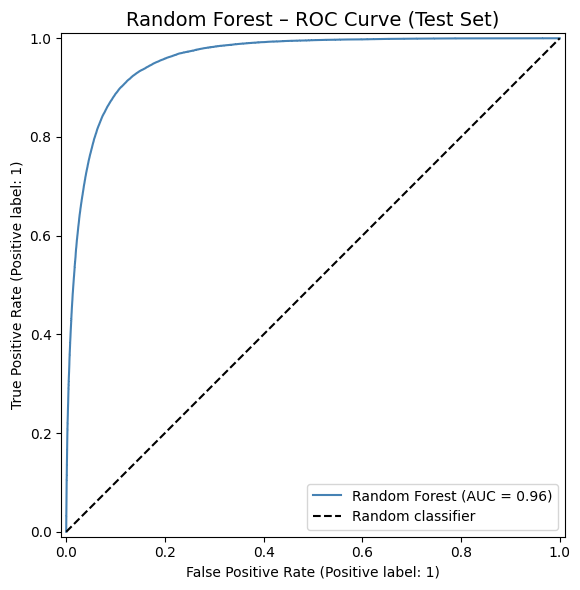

In [15]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_test_prob,
    name='Random Forest',
    color='steelblue',
    ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('Random Forest – ROC Curve (Test Set)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/rf_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

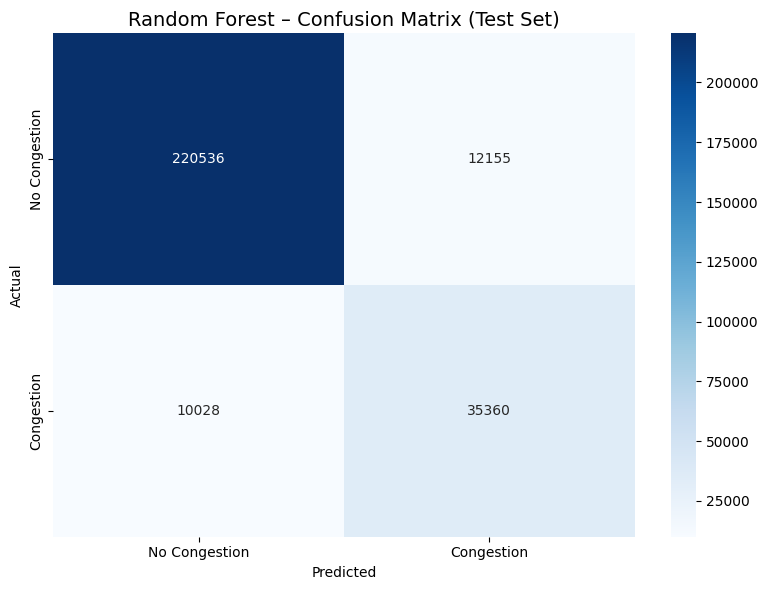

True Negatives:  220,536
False Positives: 12,155
False Negatives: 10,028
True Positives:  35,360


In [16]:
cm_test = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Congestion', 'Congestion'],
            yticklabels=['No Congestion', 'Congestion'])
ax.set_title('Random Forest – Confusion Matrix (Test Set)',
             fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/figures/rf_confusion_matrix_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_test.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

In [17]:
# Save best RF model
joblib.dump(rf_config2, 'models/random_forest_best.pkl')
size = os.path.getsize('models/random_forest_best.pkl')
print(f"Best model saved!")
print(f"Model size: {size/1024/1024:.1f} MB")

Best model saved!
Model size: 535.7 MB
